# 04 · Pré-treino — *Lilian*

**Entra:** `GPTModel` (03) + dataloader (01). **Sai:** um modelo que aprendeu algo + os **pesos oficiais do GPT-2** → base dos notebooks 05 e 06.

Perguntas:
1. Como o modelo aprende? O que é a loss?
2. Removendo LayerNorm / FFN ou usando ReLU — o que muda **no treino**?
3. Temperatura e top-k: por que o texto muda?
4. Dá para pré-treinar um GPT-2 de verdade aqui? (spoiler: não — carregamos os pesos da OpenAI)

In [1]:
import contextlib
import io
import time

import matplotlib.pyplot as plt
import tiktoken
import torch

from aula import GPT_CONFIG_124M, device, the_verdict, load_gpt2, variante
from llms_from_scratch.ch02 import create_dataloader_v1
from llms_from_scratch.ch04 import GPTModel
from llms_from_scratch.ch05 import (train_model_simple, calc_loss_loader, generate,
                                    text_to_token_ids, token_ids_to_text)

print("device:", device)
bpe = tiktoken.get_encoding("gpt2")

device: mps


## 1. A loss: quão surpreso o modelo fica com o token certo
`cross_entropy` = −log(probabilidade dada ao token correto). Modelo aleatório ≈ −log(1/50257) ≈ 10,8.

In [2]:
cfg = {**GPT_CONFIG_124M, "context_length": 256}  # contexto menor = treino mais rápido
texto = the_verdict()
corte = int(0.9 * len(texto))
train_loader = create_dataloader_v1(texto[:corte], batch_size=2, max_length=256, stride=256, shuffle=True, drop_last=True)
val_loader = create_dataloader_v1(texto[corte:], batch_size=2, max_length=256, stride=256, shuffle=False, drop_last=False)
print(len(train_loader), "batches de treino |", len(val_loader), "de validação")

torch.manual_seed(123)
model = GPTModel(cfg).to(device)
with torch.no_grad():
    print(f"loss inicial: {calc_loss_loader(train_loader, model, device):.2f}  (esperado ≈ {torch.log(torch.tensor(50257.)):.2f})")

9 batches de treino | 1 de validação


loss inicial: 10.99  (esperado ≈ 10.82)


## 2. Treinando (≈1–2 min)
Loop do livro: `forward → loss → backward (gradientes) → optimizer.step (atualiza pesos)`.

In [3]:
torch.manual_seed(123)
optimizer = torch.optim.AdamW(model.parameters(), lr=4e-4, weight_decay=0.1)
N_EPOCAS = 10
t0 = time.time()
train_losses, val_losses, tokens_vistos = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=N_EPOCAS, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=bpe,
)
print(f"\n{(time.time() - t0) / 60:.1f} min")

Ep 1 (Step 000000): Train loss 10.024, Val loss 10.134


Ep 1 (Step 000005): Train loss 8.060, Val loss 8.262


Every effort moves you, the,,,,,,,,,, the,,,,,,,,,,,,,,,, the,, the,,,, the,,,,,,,,,,,,


Ep 2 (Step 000010): Train loss 6.815, Val loss 7.078


Ep 2 (Step 000015): Train loss 5.973, Val loss 6.602


...

Ep 9 (Step 000075): Train loss 1.424, Val loss 6.214


Ep 9 (Step 000080): Train loss 1.205, Val loss 6.269


Every effort moves you know," was one of the picture. The mere outline of the frame called up all Gisburn's past!                           


Ep 10 (Step 000085): Train loss 0.881, Val loss 6.320


Every effort moves you?"  "Yes--quite insensible to the irony. She wanted him back to my work, and went on groping and Mrs. Gisburn's open countenance. "It's his ridiculous modesty, and were amusing himself by holding

0.9 min


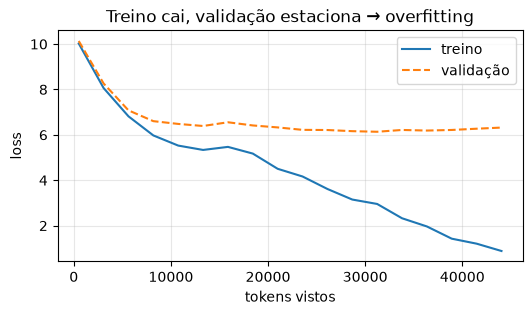

In [4]:
plt.figure(figsize=(6, 3))
plt.plot(tokens_vistos, train_losses, label="treino")
plt.plot(tokens_vistos, val_losses, "--", label="validação")
plt.xlabel("tokens vistos"); plt.ylabel("loss"); plt.legend(); plt.grid(alpha=.3)
plt.title("Treino cai, validação estaciona → overfitting")
plt.show()

O conto tem ~5 mil tokens; o GPT-2 viu ~10 **bilhões** (WebText, 40 GB). Por isso o nosso modelo decora o texto
(loss de treino → 0) mas não generaliza (validação para de cair).

## 3. Temperatura e top-k

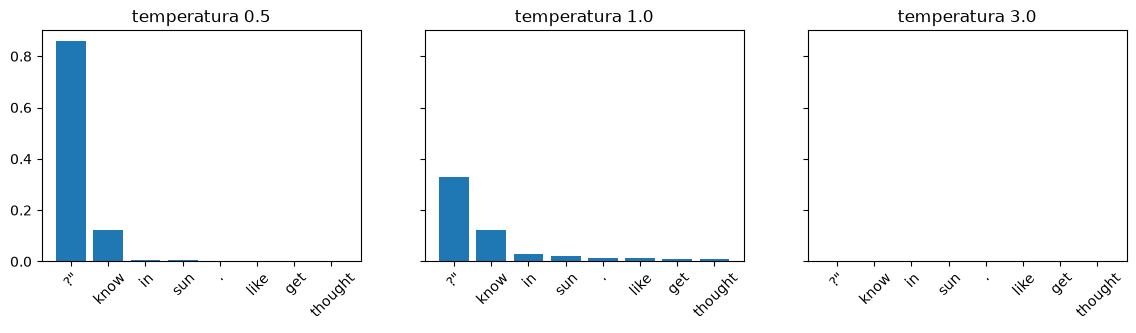

In [5]:
model.eval()
ids = text_to_token_ids("Every effort moves you", bpe).to(device)
with torch.no_grad():
    logits = model(ids)[0, -1].cpu()
top = torch.topk(logits, 8)
rotulos = [bpe.decode([i]) for i in top.indices]

fig, axs = plt.subplots(1, 3, figsize=(14, 3), sharey=True)
for ax, T in zip(axs, [0.5, 1.0, 3.0]):
    ax.bar(rotulos, torch.softmax(logits / T, -1)[top.indices])
    ax.set_title(f"temperatura {T}"); ax.tick_params(axis="x", rotation=45)
plt.show()

In [6]:
torch.manual_seed(123)
for T, k in [(0.0, None), (1.0, 25), (1.5, 25), (5.0, None)]:
    out = generate(model, ids, max_new_tokens=20, context_size=cfg["context_length"], temperature=T, top_k=k)
    print(f"T={T} top_k={k}: {token_ids_to_text(out, bpe)!r}")

T=0.0 top_k=None: 'Every effort moves you?"\n\n"Yes--quite insensible to the irony. She wanted him back to my work'


T=1.0 top_k=25: 'Every effort moves you like to work down in the Mrs. Gisburn--as such--had not it was no'


T=1.5 top_k=25: 'Every effort moves you like the easWell--ed his by a year!"\nI didn\'t let it back to G'


T=5.0 top_k=None: 'Every effort moves you Tr a)[ Mix Tiffany crit PeshFootnotelicense Lodge virtuallyMoscowKick Naked Memory ellTurkish Phant unwuations'


Temperatura < 1 concentra (repetitivo), > 1 espalha (criativo → aleatório). Top-k corta a cauda de tokens absurdos.

## 4. 🔧 Ablações **com treino**: sem LayerNorm, sem FFN, ReLU
Modelo menor (256 dims, 4 camadas) para caber em ~1 min; mesmo seed e mesmos dados para todos.

original       loss final treino=3.56  validação=6.11


sem LayerNorm  loss final treino=0.14  validação=8.85


sem FFN        loss final treino=5.64  validação=6.66


FFN com ReLU   loss final treino=3.85  validação=6.12


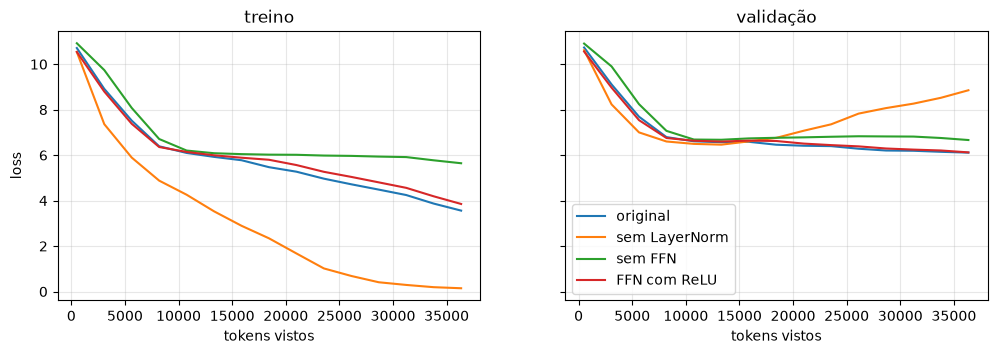

In [7]:
mini = {**cfg, "emb_dim": 256, "n_layers": 4, "n_heads": 4, "context_length": 128}
tl = create_dataloader_v1(texto[:corte], batch_size=4, max_length=128, stride=128, shuffle=True)
vl = create_dataloader_v1(texto[corte:], batch_size=4, max_length=128, stride=128, shuffle=False, drop_last=False)

curvas = {}
for nome, kw in {"original": {}, "sem LayerNorm": {"sem_norm": True}, "sem FFN": {"sem_ffn": True},
                 "FFN com ReLU": {"relu": True}}.items():
    torch.manual_seed(123)
    m = variante(mini, **kw).to(device)
    opt = torch.optim.AdamW(m.parameters(), lr=1e-3, weight_decay=0.1)
    with contextlib.redirect_stdout(io.StringIO()):  # silencia os prints do loop do livro
        tr, va, tok = train_model_simple(m, tl, vl, opt, device, num_epochs=8, eval_freq=5, eval_iter=5,
                                         start_context="Every", tokenizer=bpe)
    curvas[nome] = (tok, tr, va)
    print(f"{nome:14s} loss final treino={tr[-1]:.2f}  validação={va[-1]:.2f}")

fig, axs = plt.subplots(1, 2, figsize=(12, 3.5), sharey=True)
for nome, (tok, tr, va) in curvas.items():
    axs[0].plot(tok, tr, label=nome); axs[1].plot(tok, va, label=nome)
axs[0].set_title("treino"); axs[1].set_title("validação")
for ax in axs: ax.set_xlabel("tokens vistos"); ax.grid(alpha=.3)
axs[0].set_ylabel("loss"); axs[1].legend()
plt.show()

Leia o gráfico junto com a turma. No nosso run (M1, seed 123):
- **sem FFN** aprende mais devagar: perdeu a maior parte da capacidade;
- **sem LayerNorm** decora o treino mais rápido mas tem a **pior validação** — sinal descontrolado = otimização instável e overfitting;
- **ReLU** fica praticamente igual ao GELU nessa escala (a diferença aparece em modelos grandes e treinos longos).

## 5. Pesos de verdade: GPT-2 124M da OpenAI
Treinar isso do zero custou semanas de GPU. Carregamos os pesos (arquivo convertido para o nosso `GPTModel`).

In [8]:
gpt2, cfg_gpt2 = load_gpt2("124M")
gpt2.to(device)
torch.manual_seed(123)
out = generate(gpt2, text_to_token_ids("Every effort moves you", bpe).to(device),
               max_new_tokens=30, context_size=cfg_gpt2["context_length"], temperature=1.0, top_k=25)
print(token_ids_to_text(out, bpe))

Every effort moves you closer to enlightenment. It's the kind of life that gives you a sense of purpose, and the kind of life you need to keep going.



In [9]:
with torch.no_grad():
    print(f"loss na validação do the-verdict — nosso modelo: {calc_loss_loader(val_loader, model, device):.2f}"
          f" | GPT-2 oficial: {calc_loss_loader(val_loader, gpt2, device):.2f}")

loss na validação do the-verdict — nosso modelo: 6.38 | GPT-2 oficial: 3.56


O GPT-2 **nunca viu** esse conto e mesmo assim prevê melhor que o nosso modelo que o decorou — isso é generalização.

### Existem alternativas ao Transformer?
Sim, e várias já competem: **SSMs / Mamba** (estado recorrente, custo linear no contexto), **RWKV** (RNN treinável em paralelo),
**atenção linear / Gated DeltaNet** (usada em híbridos como Qwen3-Next e Kimi Linear — ver `ch04/08_deltanet`)
e **MoE**, que mantém o Transformer mas troca a FFN por vários especialistas (`ch04/07_moe`).
Hoje a tendência é **híbrida**: algumas camadas de atenção completa + camadas lineares.

### ✅ Construto
`load_gpt2("124M")` → modelo pré-treinado que será **ajustado** para classificar (05) e seguir instruções (06).